In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/archive (1).zip')

In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


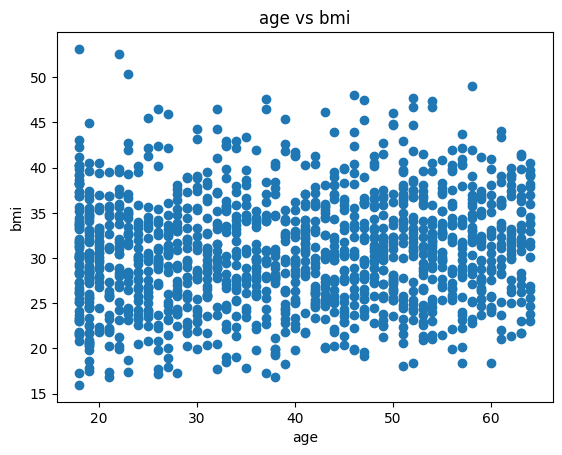

In [ ]:
plt.scatter(df['age'],df['bmi'])
plt.xlabel('age')
plt.ylabel('bmi')
plt.title('age vs bmi')
plt.show()

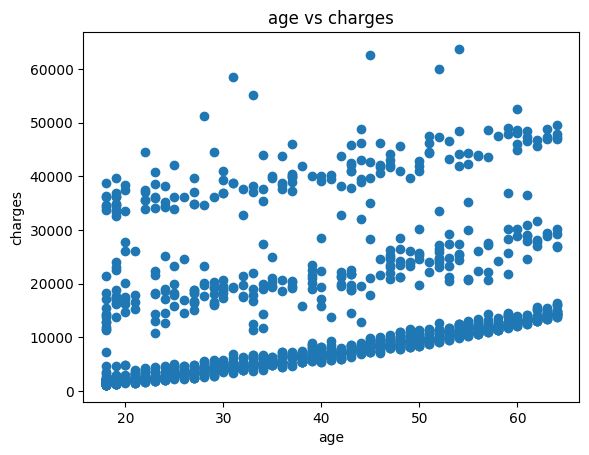

In [ ]:
plt.scatter(df['age'],df['charges'])
plt.xlabel('age')
plt.ylabel('charges')
plt.title('age vs charges')
plt.show()

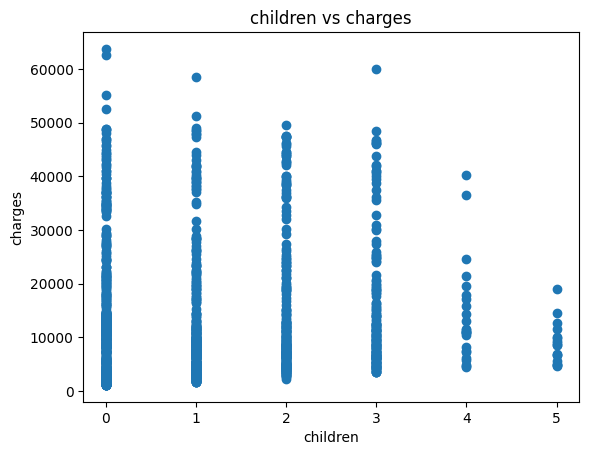

In [ ]:
plt.scatter(df['children'],df['charges'])
plt.xlabel('children')
plt.ylabel('charges')
plt.title('children vs charges')
plt.show()

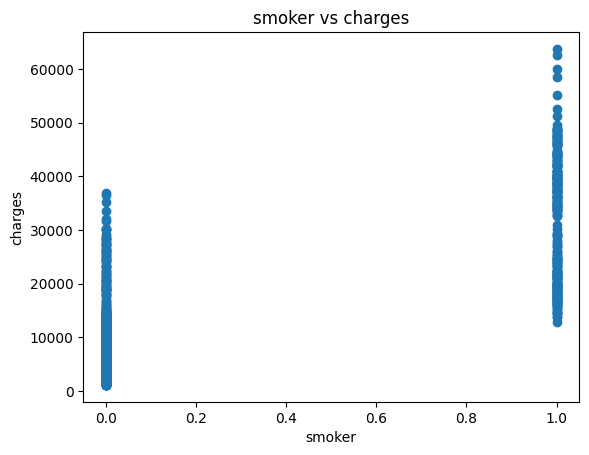

In [ ]:
plt.scatter(df['smoker'],df['charges'])
plt.xlabel('smoker')
plt.ylabel('charges')
plt.title('smoker vs charges')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()


In [ ]:
df['smoker']=le.fit_transform(df['smoker'])

df['sex']=le.fit_transform(df['sex'])


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [ ]:
df=pd.get_dummies(df,columns=["region"],drop_first=True, dtype=int)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics

from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
LR=LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred_LR=LR.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_LR)

0.7835929767120722

In [ ]:
sgd=SGDRegressor()
sgd.fit(X_train,y_train)


SGDRegressor()

In [ ]:
y_pred_sgd=sgd.predict(X_test)
r2_score(y_test,y_pred_sgd)

0.7832307195686589

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_dt=dt.predict(X_test)
r2_score(y_test,y_pred_dt)

0.6972456555791888

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 3,6, 5, 7,13],
    'min_samples_leaf': [1,2, 5, 3],
    'min_samples_split': [2,3, 5, 7],
    'splitter': ['best', 'random']
}

grid_search_dt = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
                            param_grid=param_grid,
                            cv=2,
                            scoring='r2',
                            n_jobs=-1,
                            verbose=1)

grid_search_dt.fit(X_train, y_train)

print("Best parameters found: ", grid_search_dt.best_params_)
print("Best R2 score found: ", grid_search_dt.best_score_)

Fitting 2 folds for each of 192 candidates, totalling 384 fits
Best parameters found:  {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best R2 score found:  0.8339825540606587


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(X_train,y_train)

GradientBoostingRegressor()

In [ ]:
y_pred_gbr=gbr.predict(X_test)

r2_score(y_test,y_pred_gbr)

0.8788606496647783

In [ ]:
param_grid_gbr = {
    'n_estimators': [100, 150, 50],
    'learning_rate': [0.01, 0.05, 0.1, 0.07],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}

grid_search_gbr = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                               param_grid=param_grid_gbr,
                               cv=3,
                               scoring='r2',
                               n_jobs=None,
                               verbose=0)

grid_search_gbr.fit(X_train, y_train)

print("Best parameters found for GradientBoostingRegressor: ", grid_search_gbr.best_params_)
print("Best R2 score found for GradientBoostingRegressor: ", grid_search_gbr.best_score_)

Best parameters found for GradientBoostingRegressor:  {'learning_rate': 0.07, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best R2 score found for GradientBoostingRegressor:  0.851849890852364


In [ ]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)


RandomForestRegressor()

In [ ]:
y_pred_rf=rf.predict(X_test)
r2_score(y_test,y_pred_rf)

0.8633637182413477

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 150, 50],
    'max_depth': [None,9, 7,5, 3],
    'min_samples_leaf': [1,3,2,5,7],
    'min_samples_split': [2,5,7,9]
}


grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                               param_grid=param_grid_rf,
                               cv=3,
                               scoring='r2',
                               n_jobs=None,
                               verbose=0)

grid_search_rf.fit(X_train, y_train)


print("Best parameters found for RandomForest: ", grid_search_rf.best_params_)
print("Best R2 score found for RandomForest: ", grid_search_rf.best_score_)

Best parameters found for RandomForest:  {'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 50}
Best R2 score found for RandomForest:  0.8498857669185398


In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mae_tuned_rf = mean_absolute_error(y_test, y_pred_rf)
mae_tuned_rf


2576.409827234453

In [ ]:
mae_tuned_xgb = mean_absolute_error(y_test, y_pred_xgb)
mae_tuned_xgb

2802.4253602505396

In [ ]:
mae_tuned_gbr = mean_absolute_error(y_test, y_pred_gbr)
mae_tuned_gbr

2457.479230099288

In [ ]:
mae_tuned_dt = mean_absolute_error(y_test, y_pred_dt)
mae_tuned_dt


3239.2494561343287

**Justification :** RandomForest and GradientBoostingRegressor are giving better accuracy than linear models because they consist of multiple linear models hence giving better result.

**RandomForest**: It gives r2_score of 0.86 which is higher compared to Linear Regression and SGD regression reason being charges depend on more than one feature like smoker,children,bmi and age.  

**GradientBoost**: It gives r2_score of 0.87 which is best among all applied models in dataset.Reason being it continuosly corrects errors hence giving a little better result than Randomforest.